In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

## Task 1:

In [32]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


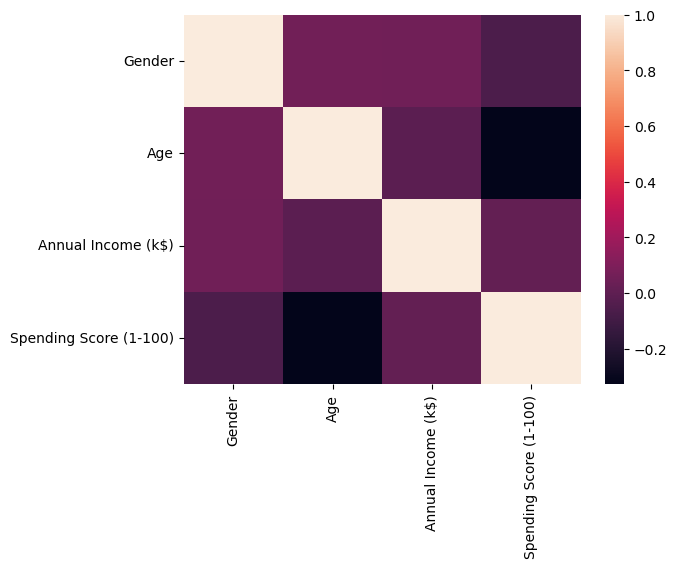

In [34]:
df.drop('CustomerID', axis=1, inplace=True)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
sns.heatmap(df.select_dtypes(include="number").corr())
plt.show()

C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

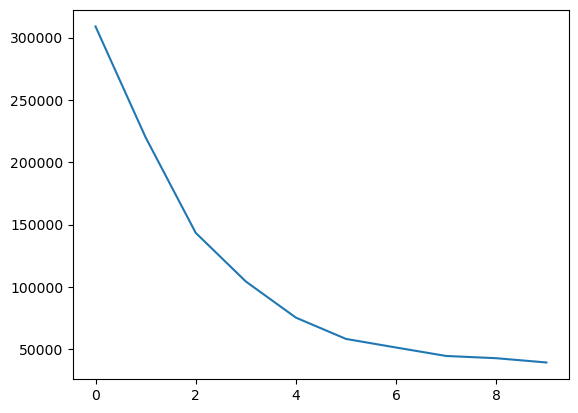

In [36]:
wcss = []
for i in range(1, 11):
  model = KMeans(i, init='k-means++', random_state=727)
  model.fit(df)
  wcss.append(model.inertia_)

sns.lineplot(wcss)
plt.show()

C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


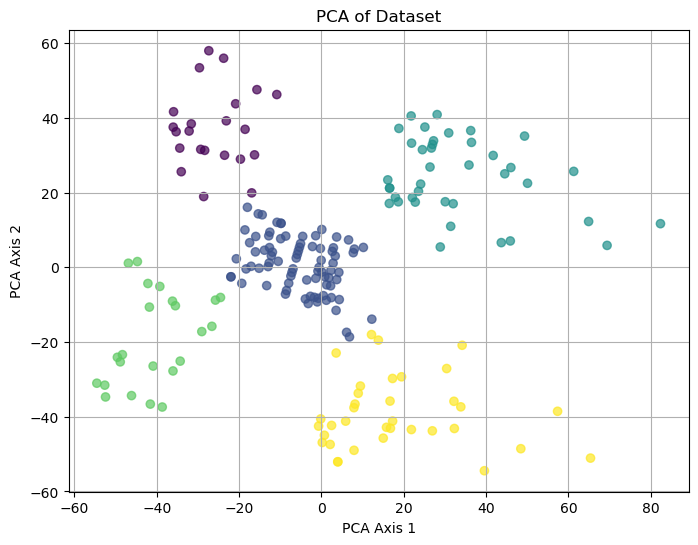

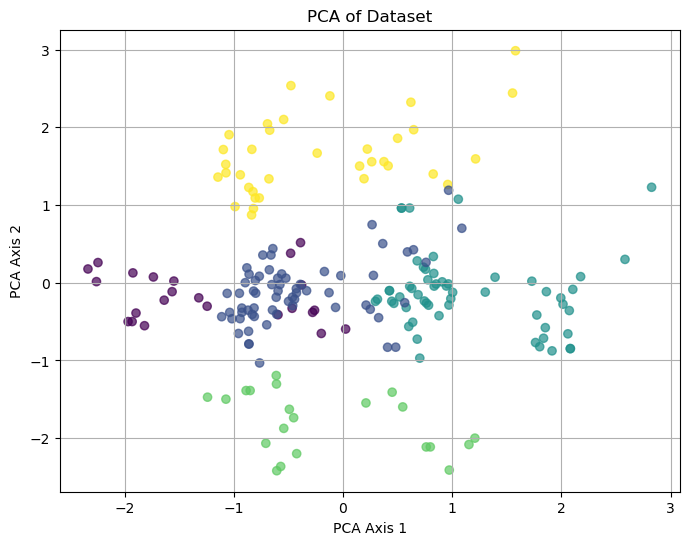

Silhouette Score (Original Data): 0.5534496268497305
Silhouette Score (Scaled Data): 0.38523772352316


In [42]:
def run_kmeans(input_data, num_clusters=5, seed=727):
    km = KMeans(n_clusters=num_clusters, init='k-means++', random_state=seed)
    return km.fit_predict(input_data)

# Exclude 'Age' column before clustering
df_without_age = df.drop(columns=['Age'])

scaler = StandardScaler()
normalized_data = scaler.fit_transform(df_without_age)

clusters_raw = run_kmeans(df_without_age)
clusters_normalized = run_kmeans(normalized_data)

def visualize_pca_projection(data, cluster_labels):
    # Reduce data dimensions to 2D using PCA
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)

    # Plot the results
    plt.figure(figsize=(8, 6))
    plt.scatter(data_2d[:, 0], data_2d[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
    plt.title("PCA of Dataset")
    plt.xlabel("PCA Axis 1")
    plt.ylabel("PCA Axis 2")
    plt.grid(True)
    plt.show()


visualize_pca_projection(df_without_age, clusters_raw)
visualize_pca_projection(normalized_data, clusters_normalized)

# Evaluating clustering quality with Silhouette Score
print("Silhouette Score (Original Data):", silhouette_score(df_without_age, clusters_raw))
print("Silhouette Score (Scaled Data):", silhouette_score(normalized_data, clusters_normalized))


## Task 2:

C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

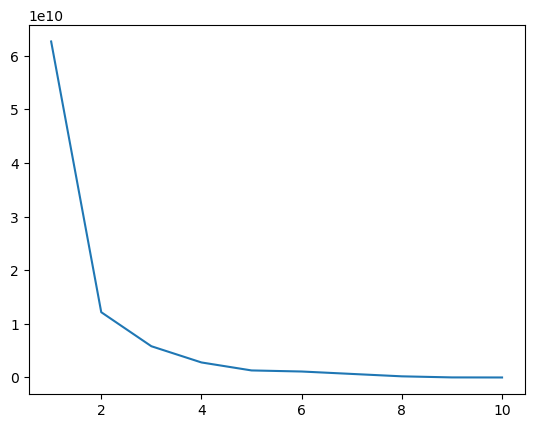

In [47]:

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)
dfwithout = df.drop('vehicle_type', axis = 1)
ss = StandardScaler()
dfscaled = ss.fit_transform(dfwithout.copy())

wccs = []
random_state = 727
for i in range(1, 11):
    model = KMeans(i, init='k-means++',random_state=random_state)
    model.fit(dfwithout)
    wccs.append(model.inertia_)

sns.lineplot(x=range(1,11), y=wccs)
plt.show()

In [61]:
predictions_normal = run_kmeans(dfwithout, num_clusters=4, seed=random_state)
predictions_scaled = run_kmeans(dfscaled, num_clusters=4, seed=random_state)

print(silhouette_score(dfwithout, predictions_normal))
print(silhouette_score(dfscaled, predictions_scaled))

0.4738887642684584
0.5085133756383747


C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Task 3:

C:\Users\Amna\AppData\Local\Temp\ipykernel_19156\3989499383.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=dfwithout, x='mileage', y='maintenance_cost', palette='Set1')


TypeError: Data source must be a DataFrame or Mapping, not <class 'numpy.ndarray'>.

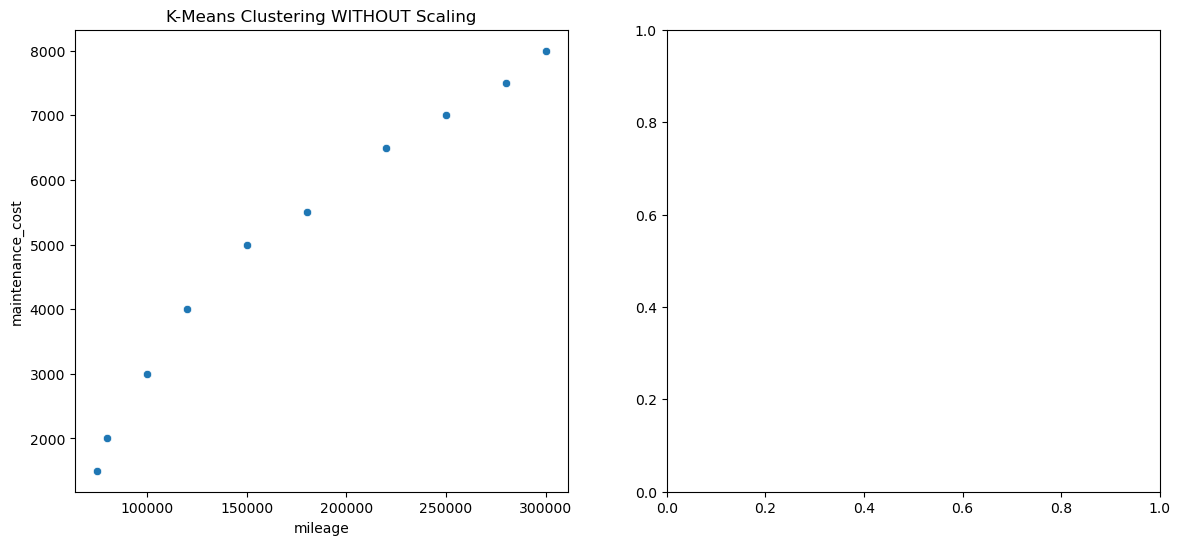

In [11]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=dfwithout, x='mileage', y='maintenance_cost'import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# Step 1: Sample Student Data
# --------------------------
data = {
    'student_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'GPA': [3.6, 2.8, 3.2, 2.0, 3.9, 2.5, 3.5, 3.0, 2.2, 3.8],
    'study_hours': [20, 10, 15, 5, 25, 7, 18, 13, 6, 22],
    'attendance_rate': [90, 60, 75, 40, 95, 50, 88, 70, 45, 92]
}
df = pd.DataFrame(data)

# --------------------------
# Step 2: Feature Selection & Scaling
# --------------------------
features = df[['GPA', 'study_hours', 'attendance_rate']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# --------------------------
# Step 3: Determine Optimal K (Elbow Method)
# --------------------------
sse = []
k_range = range(2, 7)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

# --------------------------
# Step 4: Apply KMeans with optimal K (assume K=3 based on elbow)
# --------------------------
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans_final.fit_predict(scaled_features)

# --------------------------
# Step 5: Visualization
# --------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='study_hours', y='GPA', hue='cluster', palette='Set1', s=100)
plt.title('Student Clusters by Study Hours and GPA')
plt.xlabel('Average Weekly Study Hours')
plt.ylabel('GPA')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# --------------------------
# Step 6: Final Output Dataset
# --------------------------
print("Final Student Cluster Assignments:")
print(df[['student_id', 'GPA', 'study_hours', 'attendance_rate', 'cluster']])
, palette='Set1')
plt.title("K-Means Clustering WITHOUT Scaling")

plt.subplot(1, 2, 2)
sns.scatterplot(data=dfscaled, x='mileage', y='maintenance_cost', palette='Set2')
plt.title("K-Means Clustering WITH Scaling")

plt.tight_layout()
plt.show()

C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

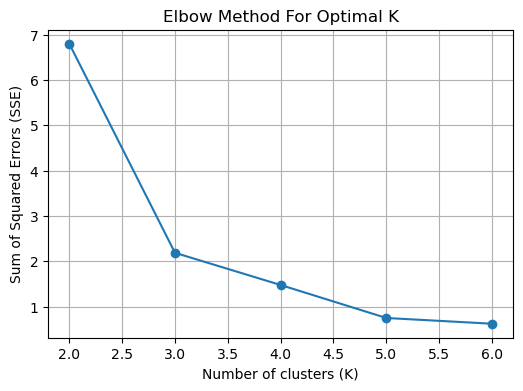

C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


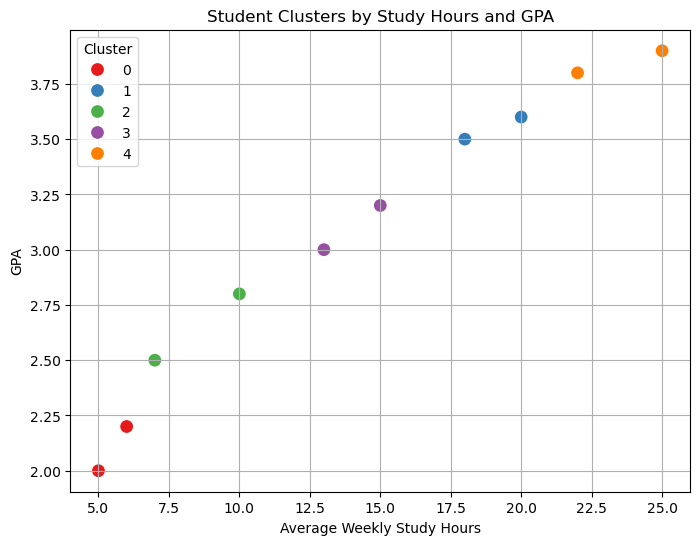

Final Student Cluster Assignments:
   student_id  GPA  study_hours  attendance_rate  cluster
0         101  3.6           20               90        1
1         102  2.8           10               60        2
2         103  3.2           15               75        3
3         104  2.0            5               40        0
4         105  3.9           25               95        4
5         106  2.5            7               50        2
6         107  3.5           18               88        1
7         108  3.0           13               70        3
8         109  2.2            6               45        0
9         110  3.8           22               92        4


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# Step 1: Sample Student Data
# --------------------------
data = {
    'student_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'GPA': [3.6, 2.8, 3.2, 2.0, 3.9, 2.5, 3.5, 3.0, 2.2, 3.8],
    'study_hours': [20, 10, 15, 5, 25, 7, 18, 13, 6, 22],
    'attendance_rate': [90, 60, 75, 40, 95, 50, 88, 70, 45, 92]
}
df = pd.DataFrame(data)

# --------------------------
# Step 2: Feature Selection & Scaling
# --------------------------
features = df[['GPA', 'study_hours', 'attendance_rate']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# --------------------------
# Step 3: Determine Optimal K (Elbow Method)
# --------------------------
sse = []
k_range = range(2, 7)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

# --------------------------
# Step 4: Apply KMeans with optimal K (assume K=3 based on elbow)
# --------------------------
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans_final.fit_predict(scaled_features)

# --------------------------
# Step 5: Visualization
# --------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='study_hours', y='GPA', hue='cluster', palette='Set1', s=100)
plt.title('Student Clusters by Study Hours and GPA')
plt.xlabel('Average Weekly Study Hours')
plt.ylabel('GPA')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# --------------------------
# Step 6: Final Output Dataset
# --------------------------
print("Final Student Cluster Assignments:")
print(df[['student_id', 'GPA', 'study_hours', 'attendance_rate', 'cluster']])


In [19]:
#importing libraries
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Importing the dataset
df = pd.read_csv('Mall_Customers.csv')
df.head()
# Extracting Variables
x = df.iloc[:, [3, 4]].values
#finding optimal number of clusters using the elbow method
from sklearn.cluster import KMeans
wcss_list= [] #Initializing the list for the values of WCSS
#Using for loop for iterations from 1 to 10.
for i in range(1, 11):
kmeans = KMeans(n_clusters=i, init=&#39;k-means++&#39;, random_state= 42)
kmeans.fit(x)
wcss_list.append(kmeans.inertia_)
mtp.plot(range(1, 11), wcss_list)
mtp.title('The Elobw Method Graph')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')

mtp.show()
# Normalize features for better clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
#training the K-means model on a dataset
kmeans = KMeans(n_clusters=5, init=&#39;k-means++&#39;, random_state= 42)
y_predict= kmeans.fit_predict(X_scaled)

#visulaizing the clusters
mtp.scatter(x[y_predict == 0, 0], x[y_predict == 0, 1], s = 100, c =
&#39;blue&#39;, label = &#39;Cluster 1&#39;) #for first cluster
mtp.scatter(x[y_predict == 1, 0], x[y_predict == 1, 1], s = 100, c =
&#39;green&#39;, label = &#39;Cluster 2&#39;) #for second cluster
mtp.scatter(x[y_predict== 2, 0], x[y_predict == 2, 1], s = 100, c =
&#39;red&#39;, label = &#39;Cluster 3&#39;) #for third cluster
mtp.scatter(x[y_predict == 3, 0], x[y_predict == 3, 1], s = 100, c =
&#39;black&#39;, label = &#39;Cluster 4&#39;) #for fourth cluster
mtp.scatter(x[y_predict == 4, 0], x[y_predict == 4, 1], s = 100, c =
&#39;purple&#39;, label = &#39;Cluster 5&#39;) #for fifth cluster
mtp.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,
1], s = 300, c = &#39;yellow&#39;, label = &#39;Centroid&#39;)
mtp.title(&#39;Clusters of customers&#39;)
mtp.xlabel(&#39;Annual Income (k$)&#39;)
mtp.ylabel(&#39;Spending Score (1-100)&#39;)
mtp.legend()
mtp.show()

SyntaxError: invalid syntax (1835588693.py, line 9)

C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Amna\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


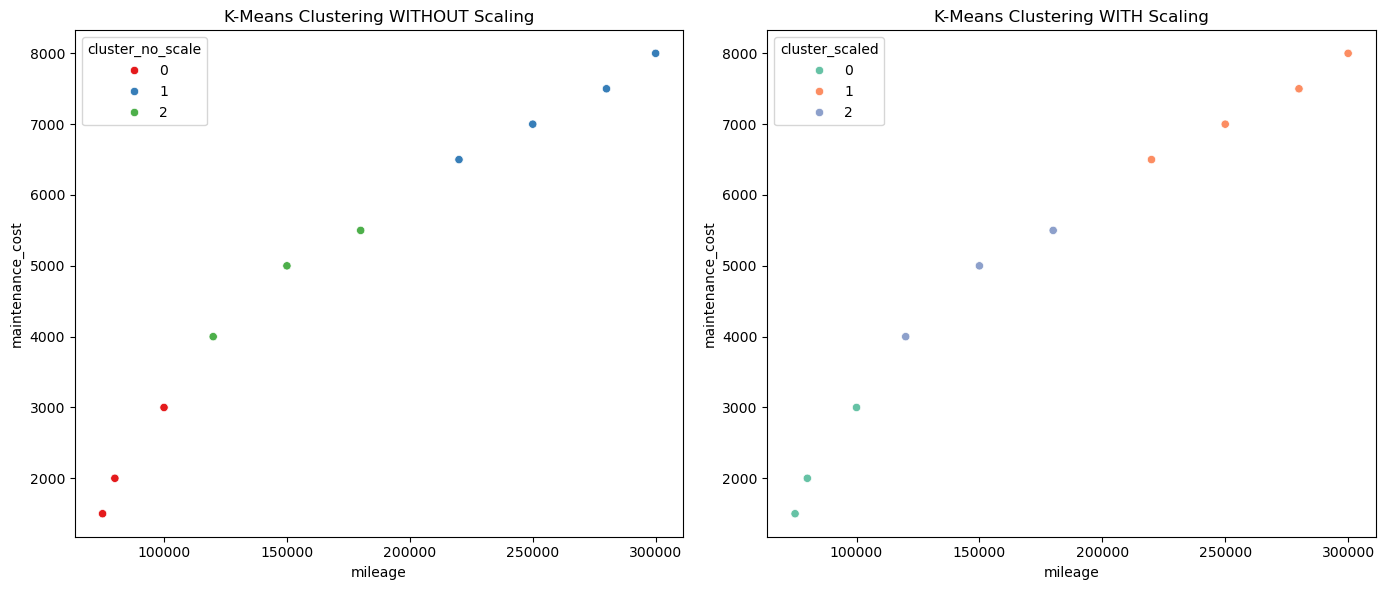

=== Cluster Centroids WITHOUT Scaling ===
    mileage  fuel_efficiency  maintenance_cost
0   85000.0        22.000000       2166.666667
1  262500.0         9.750000       7250.000000
2  150000.0        16.333333       4833.333333

=== Cluster Centroids WITH Scaling ===
    mileage  fuel_efficiency  maintenance_cost
0 -1.143624         1.241971         -1.293234
1  1.099396        -1.063203          1.026980
2 -0.322237         0.175632         -0.076073


In [22]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Sample Data
data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}
df = pd.DataFrame(data)

# Encode 'vehicle_type' as numbers for visualization only
df['vehicle_type_encoded'] = df['vehicle_type'].astype('category').cat.codes

# -------------------------------
# Clustering without scaling
# -------------------------------
features_no_scale = df[['mileage', 'fuel_efficiency', 'maintenance_cost']]
kmeans_no_scale = KMeans(n_clusters=3, random_state=42)
df['cluster_no_scale'] = kmeans_no_scale.fit_predict(features_no_scale)

# -------------------------------
# Clustering with scaling
# -------------------------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_no_scale)

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
df['cluster_scaled'] = kmeans_scaled.fit_predict(scaled_features)

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='mileage', y='maintenance_cost', hue='cluster_no_scale', palette='Set1')
plt.title("K-Means Clustering WITHOUT Scaling")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='mileage', y='maintenance_cost', hue='cluster_scaled', palette='Set2')
plt.title("K-Means Clustering WITH Scaling")

plt.tight_layout()
plt.show()

# -------------------------------
# Analysis
# -------------------------------
print("=== Cluster Centroids WITHOUT Scaling ===")
print(pd.DataFrame(kmeans_no_scale.cluster_centers_, columns=features_no_scale.columns))
print("\n=== Cluster Centroids WITH Scaling ===")
print(pd.DataFrame(kmeans_scaled.cluster_centers_, columns=['mileage', 'fuel_efficiency', 'maintenance_cost']))
